In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [13]:
from drawdata import ScatterWidget
widget = ScatterWidget()
widget

In [31]:
data = widget.data_as_pandas
data

,x,y,color,label,batch
0,285.935955,84.352474,#1f77b4,a,0
1,256.508786,49.048115,#1f77b4,a,0
2,230.060244,99.463737,#1f77b4,a,0
3,248.611447,27.768686,#1f77b4,a,0
4,237.131428,87.753495,#1f77b4,a,0
...,...,...,...,...,...
273,371.039413,130.582144,#1f77b4,a,3
274,378.767916,127.375715,#1f77b4,a,3
275,378.447702,89.836387,#1f77b4,a,3
276,371.621117,99.694970,#1f77b4,a,3


In [32]:
X = data.x.values.reshape(-1,1) #separamos x e y
y = data.y.values.reshape(-1,1)


In [33]:
#matriz de diseño
phi = np.hstack((np.ones((X.shape[0],1)),X)) #agregamos el termino de sesgox    
phi

array([[  1.        , 285.93595528],
       [  1.        , 256.50878617],
       [  1.        , 230.06024442],
       [  1.        , 248.61144736],
       [  1.        , 237.13142776],
       [  1.        , 269.69240616],
       [  1.        , 277.58724044],
       [  1.        , 299.36709001],
       [  1.        , 305.44232303],
       [  1.        , 331.53739683],
       [  1.        , 289.71877614],
       [  1.        , 325.30216148],
       [  1.        , 356.45534328],
       [  1.        , 357.64328928],
       [  1.        , 287.80193869],
       [  1.        , 351.53474832],
       [  1.        , 305.96306928],
       [  1.        , 359.89002353],
       [  1.        , 336.67689854],
       [  1.        , 330.37395091],
       [  1.        , 311.81488493],
       [  1.        , 356.30006128],
       [  1.        , 359.93774379],
       [  1.        , 337.32246265],
       [  1.        , 322.86675193],
       [  1.        , 290.18763739],
       [  1.        , 324.73315423],
 

In [34]:
pseudo_inversa = np.linalg.inv(phi.T @ phi) @ phi.T #calculamos la pseudo inversa


In [35]:
params = pseudo_inversa @ y #calculamos los parametros
np.round(params,2)

array([[ 2.7271e+02],
       [-2.2000e-01]])

<Axes: xlabel='x', ylabel='y'>

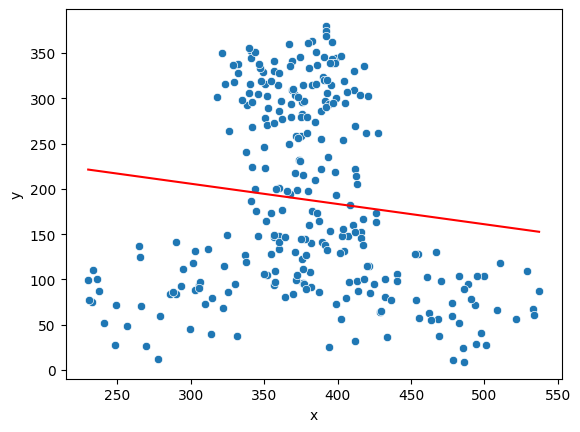

In [36]:
X_linspace = np.linspace(X.min(),X.max(),100)    #creamos un vector de 100 puntos entre el minimo y maximo de x
sns.scatterplot(x="x",y="y",data=data) #graficamos los datos
y_pred = params[0] + params[1]*X_linspace #calculamos las predicciones
sns.lineplot(x=X_linspace,y=y_pred,color="red") #graficamos la recta de regresion

In [43]:
X = (X - X.mean())/X.std() #normalizamos los datos
y = (y - y.mean())/y.std() #normalizamos la respuesta
phi = np.hstack((np.ones((X.shape[0],1)),X)) #matriz de diseño con los datos normalizados

## Gradiente estocástico

In [44]:
w = np.zeros((2,1)) #inicializamos los pesos en 0
w

array([[0.],
       [0.]])

In [48]:
phi=np.array([np.ones(len(X)), X]).T
phi

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 278) + inhomogeneous part.

In [47]:
#setear un learning rate (n rara)
w = np.array([[0],[0]]) #inicializamos los pesos en 0
lr = 0.1
w, lr

(array([[0],
        [0]]),
 0.1)

In [ ]:
#phi, y #data y respuesta
epochs = 100 #cuantos pasos realizar (epocas)
for epoch in range(epochs):
    ols = 0.5*(y -phi @ w)**2 #calculamos el error ordinary least squares
    grad = phi.T @ (y - phi @ w) #calculamos el gradiente
    w = w + lr*grad #actualizamos los pesos
    #errors.append(ols.mean()) #guardamos el error para graficar despues
w 
 


array([[5.85945263e+128],
       [8.12977422e+141]])